# PyTorch Model Pruning Tutorial
이 노트북에서는 간단한 CNN 모델을 학습시킨 후, **Global Unstructured Pruning** 기법을 사용하여 모델의 가중치(Weight)를 경량화하는 과정을 다룹니다.

**진행 순서:**
1. 데이터 로드 및 모델 정의
2. 모델 학습 (Training)
3. Pruning 전 가중치 분포 시각화
4. Pruning 적용 (하위 40% 제거)
5. 결과 분석 (Sparsity 및 정확도 확인)



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.utils.prune as prune
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Random Seed 고정 (재현성을 위해)
torch.manual_seed(42)

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# 1. 데이터셋 준비
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)

# 2. 모델 정의
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=3)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=3)
        self.fc1 = nn.Linear(500, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = x.view(-1, 500)
        x = self.fc1(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=500, out_features=10, bias=True)
)


In [ ]:
def train_model(model, trainloader, epochs=1):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    print(f"--- Training for {epochs} Epoch(s) ---")
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
    print("--- Training Completed ---")

def evaluate_accuracy(model, testloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Model Accuracy: {accuracy:.2f}%')
    return accuracy

def get_sparsity(model):
    global_zeros = 0
    global_elements = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            weight = module.weight.data
            num_zeros = torch.sum(weight == 0).item()
            num_elements = weight.nelement()
            global_zeros += num_zeros
            global_elements += num_elements

    return 100. * global_zeros / global_elements

In [ ]:
# 초기 정확도 확인
print("Before Training:")
evaluate_accuracy(model, testloader)

# 모델 학습 (빠른 실습을 위해 1 Epoch)
train_model(model, trainloader, epochs=1)

# 학습 후 정확도 확인
print("\nAfter Training:")
evaluate_accuracy(model, testloader)

Before Training:
Model Accuracy: 10.28%
--- Training for 1 Epoch(s) ---
--- Training Completed ---

After Training:
Model Accuracy: 97.39%


97.39

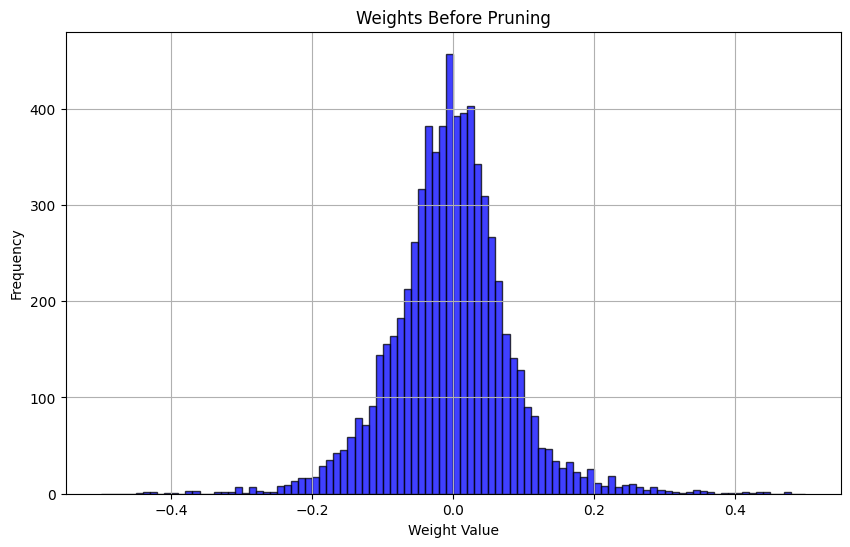

In [ ]:
def plot_weights_distribution(model, title="Weight Distribution"):
    weights = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            # Flatten weights and move to CPU
            weights.extend(module.weight.data.cpu().view(-1).numpy())

    plt.figure(figsize=(10, 6))
    plt.hist(weights, bins=100, range=(-0.5, 0.5), alpha=0.75, color='blue', edgecolor='black')
    plt.title(title)
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# Pruning 전 분포 확인
plot_weights_distribution(model, "Weights Before Pruning")

In [ ]:
print("--- Applying Pruning ---")

# Pruning 대상 레이어 및 파라미터 선정
parameters_to_prune = (
    (model.conv1, 'weight'),
    (model.conv2, 'weight'),
    (model.fc1, 'weight'),
)

# Global Unstructured Pruning: 전체 가중치 중 절댓값이 가장 작은 40%를 0으로 만듦
prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.1,
)

# Sparsity 및 정확도 확인
current_sparsity = get_sparsity(model)
print(f"Current Model Sparsity: {current_sparsity:.2f}%")

print("\nAccuracy After Pruning:")
evaluate_accuracy(model, testloader)

--- Applying Pruning ---
Current Model Sparsity: 75.01%

Accuracy After Pruning:
Model Accuracy: 93.42%


93.42

Pruning made permanent.


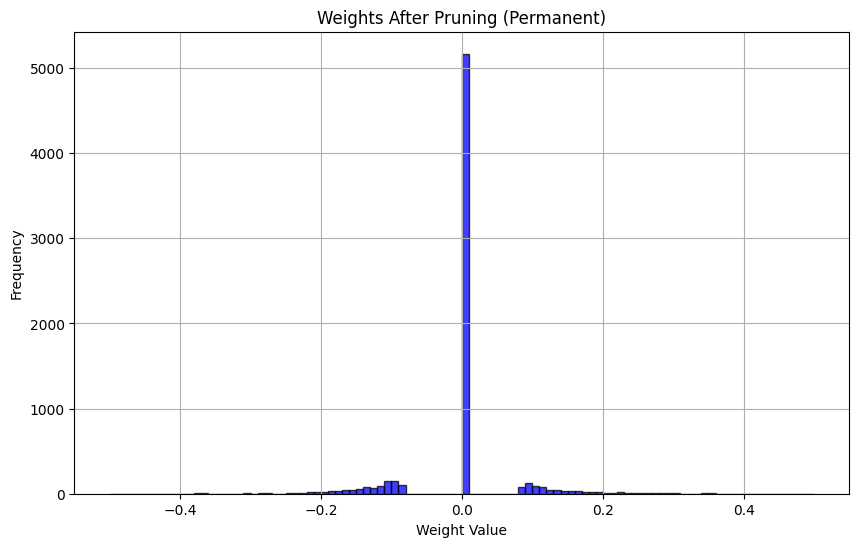

In [ ]:
# Pruning 효과 시각화 (0 근처에 값이 몰려있는지 확인)
# 주의: 현재는 마스크가 적용된 상태이므로, 시각화를 위해 weight_mask를 곱한 값을 사용하거나
# 영구 적용(remove) 후 확인해야 함. 여기서는 바로 영구 적용을 수행.

# Pruning 영구 적용 (Mask 삭제 및 Weight에 반영)
for module, param_name in parameters_to_prune:
    prune.remove(module, param_name)

print("Pruning made permanent.")

# 최종 가중치 분포 확인 (0인 값이 압도적으로 많아져야 함)
plot_weights_distribution(model, "Weights After Pruning (Permanent)")